# MLS Winner Prediction and Feature Importance

This notebook uses real Major League Soccer results to predict match outcomes, find the stats that
matter most, and simulate the rest of the season to estimate who wins the title.

**Dataset:** mls_matches.csv (2020 to 2026)

Sections:
- Part 1 - Data Preprocessing
- Part 2 - Feature Engineering
- Part 3 - Training the Models
- Part 4 - Evaluating the Models
- Part 5 - Feature Importance
- Part 6 - Predicting the Season Winner
- Part 7 - Predicting a Single Match

## Part 1 - Data Preprocessing

### Importing the libraries
Loading pandas and numpy for the data, and matplotlib and seaborn for the charts.

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Importing the dataset
Reading the CSV and remove the timezone from the date column so date maths is simple later.

In [3]:
data = pd.read_csv("mls_matches.csv", parse_dates=["date"])
data["date"] = data["date"].dt.tz_localize(None)
data.head()

,date,season,home_team,away_team,home_goals,away_goals
0,2020-02-29 18:00:00,2020,DC United,Colorado Rapids,1,2
1,2020-02-29 20:00:00,2020,CF Montréal,New England Revolution,2,1
2,2020-02-29 20:30:00,2020,Houston Dynamo,LA Galaxy,1,1
3,2020-02-29 22:30:00,2020,San Jose Earthquakes,Toronto FC,2,2
4,2020-02-29 23:00:00,2020,Orlando City SC,Real Salt Lake,0,0


### Checking the data
A quick look at the size and how many matches we have per season.

In [4]:
print(data.shape)
print(data["season"].value_counts().sort_index())

(3136, 6)
season
2020    324
2021    472
2022    489
2023    521
2024    522
2025    540
2026    268
Name: count, dtype: int64


### Adding the conferences
MLS has an Eastern and a Western conference and each keeps its own table. We need this for league position and for the playoff at the end.

In [5]:
east = ["Atlanta United", "CF Montréal", "Charlotte FC", "Chicago Fire", "Columbus Crew",
        "DC United", "FC Cincinnati", "Inter Miami CF", "Nashville SC", "New England Revolution",
        "New York City FC", "New York Red Bulls", "Orlando City SC", "Philadelphia Union", "Toronto FC"]

west = ["Austin FC", "Colorado Rapids", "FC Dallas", "Houston Dynamo", "LA Galaxy",
        "Los Angeles FC", "Minnesota United", "Portland Timbers", "Real Salt Lake", "San Diego FC",
        "San Jose Earthquakes", "Seattle Sounders FC", "Sporting Kansas City", "St.Louis City",
        "Vancouver Whitecaps"]

conference = {}
for team in east:
    conference[team] = "East"
for team in west:
    conference[team] = "West"

len(conference)

30

### Creating the result column
The target we want to predict: H for a home win, D for a draw, A for an away win.

In [6]:
data["result"] = "D"
data.loc[data["home_goals"] > data["away_goals"], "result"] = "H"
data.loc[data["home_goals"] < data["away_goals"], "result"] = "A"

data["result"].value_counts()

,count
result,
H,1475
A,852
D,809


### Looking at the outcomes
Home teams win most often. This home advantage is the baseline any model has to beat.

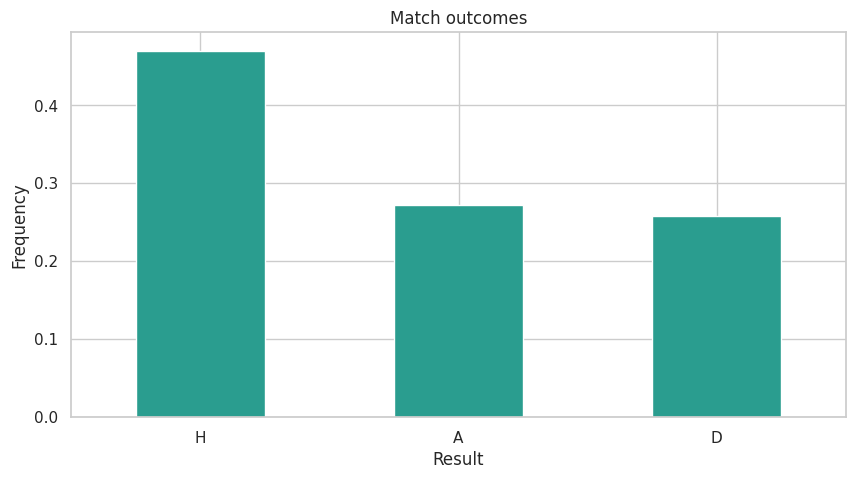

In [7]:
data["result"].value_counts(normalize=True).plot(kind="bar", color="#2a9d8f", rot=0)
plt.title("Match outcomes")
plt.xlabel("Result")
plt.ylabel("Frequency")
plt.show()

### Building a team-by-team table
As of now, each match is one row with a home and an away team. To measure a team's recent form we need all of its games on one timeline, no matter where it played. So we stack the data: one row for the home team's view, and one row for the away team's view.

In [8]:
home = data.copy()
home["team"] = data["home_team"]
home["opponent"] = data["away_team"]
home["is_home"] = 1
home["goals_for"] = data["home_goals"]
home["goals_against"] = data["away_goals"]

away = data.copy()
away["team"] = data["away_team"]
away["opponent"] = data["home_team"]
away["is_home"] = 0
away["goals_for"] = data["away_goals"]
away["goals_against"] = data["home_goals"]

games = pd.concat([home, away], ignore_index=True)
games.shape

(6272, 12)

In [9]:
games.head()

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,goals_for,goals_against
0,2020-02-29 18:00:00,2020,DC United,Colorado Rapids,1,2,A,DC United,Colorado Rapids,1,1,2
1,2020-02-29 20:00:00,2020,CF Montréal,New England Revolution,2,1,H,CF Montréal,New England Revolution,1,2,1
2,2020-02-29 20:30:00,2020,Houston Dynamo,LA Galaxy,1,1,D,Houston Dynamo,LA Galaxy,1,1,1
3,2020-02-29 22:30:00,2020,San Jose Earthquakes,Toronto FC,2,2,D,San Jose Earthquakes,Toronto FC,1,2,2
4,2020-02-29 23:00:00,2020,Orlando City SC,Real Salt Lake,0,0,D,Orlando City SC,Real Salt Lake,1,0,0


### Adding points and goal difference
Three points for a win, one for a draw, zero for a loss. This is the base for every form feature.

In [10]:
games["points"] = 1
games.loc[games["goals_for"] > games["goals_against"], "points"] = 3
games.loc[games["goals_for"] < games["goals_against"], "points"] = 0

games["conference"] = games["team"].map(conference)
games = games.sort_values(["team", "date"]).reset_index(drop=True)
games.head()

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,goals_for,goals_against,points,conference
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,2,1,3,East
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,2,1,3,East
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,0,1,0,East
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,0,1,0,East
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,0,1,0,East


## Part 2 - Feature Engineering

Every feature below is shifted by one game with .shift(1). This is the most important idea in the
whole notebook: it makes sure a row only ever uses information from BEFORE the match. Without it our
model would secretly see the result it is trying to predict and look far more accurate than it really
is. That mistake is called data leakage.

### Recent form: points per game
Average points over each team's last 5 and last 10 games. We sort by team and date first so each rolling window follows that team's own timeline.

In [11]:
games = games.sort_values(["team", "date"])

games["ppg_5"] = games.groupby("team")["points"].shift(1).rolling(5, min_periods=1).mean()
games["ppg_10"] = games.groupby("team")["points"].shift(1).rolling(10, min_periods=1).mean()

In [12]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,goals_for,goals_against,points,conference,ppg_5,ppg_10
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,2,1,3,East,NaN,NaN
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,2,1,3,East,3.0,3.000000
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,0,1,0,East,3.0,3.000000
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,0,1,0,East,2.0,2.000000
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,0,1,0,East,1.5,1.500000
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,2,0,3,East,1.2,1.200000
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,1,3,0,East,1.2,1.500000
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,0,0,1,East,0.6,1.285714
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,1,1,1,East,0.8,1.250000
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,1,2,0,East,1.0,1.222222


### Recent form: win rate
How often the team has won in its last 10 games.

In [13]:
games["won"] = (games["points"] == 3).astype(int)
games["win_rate_10"] = games.groupby("team")["won"].shift(1).rolling(10, min_periods=1).mean()

In [14]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,goals_for,goals_against,points,conference,ppg_5,ppg_10,won,win_rate_10
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,2,1,3,East,NaN,NaN,1,NaN
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,2,1,3,East,3.0,3.000000,1,1.000000
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,0,1,0,East,3.0,3.000000,0,1.000000
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,0,1,0,East,2.0,2.000000,0,0.666667
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,0,1,0,East,1.5,1.500000,0,0.500000
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,2,0,3,East,1.2,1.200000,1,0.400000
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,1,3,0,East,1.2,1.500000,0,0.500000
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,0,0,1,East,0.6,1.285714,0,0.428571
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,1,1,1,East,0.8,1.250000,0,0.375000
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,1,2,0,East,1.0,1.222222,0,0.333333


### Goals scored and conceded
Average goals for and against over the last 5 games. This shows how the team has been attacking and defending recently.

In [15]:
games["goals_for_5"] = games.groupby("team")["goals_for"].shift(1).rolling(5, min_periods=1).mean()
games["goals_against_5"] = games.groupby("team")["goals_against"].shift(1).rolling(5, min_periods=1).mean()

In [16]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,goals_for,goals_against,points,conference,ppg_5,ppg_10,won,win_rate_10,goals_for_5,goals_against_5
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,2,1,3,East,NaN,NaN,1,NaN,NaN,NaN
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,2,1,3,East,3.0,3.000000,1,1.000000,2.000000,1.0
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,0,1,0,East,3.0,3.000000,0,1.000000,2.000000,1.0
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,0,1,0,East,2.0,2.000000,0,0.666667,1.333333,1.0
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,0,1,0,East,1.5,1.500000,0,0.500000,1.000000,1.0
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,2,0,3,East,1.2,1.200000,1,0.400000,0.800000,1.0
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,1,3,0,East,1.2,1.500000,0,0.500000,0.800000,0.8
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,0,0,1,East,0.6,1.285714,0,0.428571,0.600000,1.2
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,1,1,1,East,0.8,1.250000,0,0.375000,0.600000,1.0
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,1,2,0,East,1.0,1.222222,0,0.333333,0.800000,1.0


### Home and away strength
Some teams are strong at home and weak away. We build a running points-per-game for each team split by where it played.

In [17]:
games["home_points"] = games["points"].where(games["is_home"] == 1)
games["away_points"] = games["points"].where(games["is_home"] == 0)

games["home_ppg"] = games.groupby("team")["home_points"].shift(1).expanding().mean().reset_index(level=0, drop=True)
games["away_ppg"] = games.groupby("team")["away_points"].shift(1).expanding().mean().reset_index(level=0, drop=True)

games["home_ppg"] = games.groupby("team")["home_ppg"].ffill()
games["away_ppg"] = games.groupby("team")["away_ppg"].ffill()
games[["home_ppg", "away_ppg"]] = games[["home_ppg", "away_ppg"]].fillna(1.3)

In [18]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,...,ppg_5,ppg_10,won,win_rate_10,goals_for_5,goals_against_5,home_points,away_points,home_ppg,away_ppg
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,...,NaN,NaN,1,NaN,NaN,NaN,NaN,3.0,1.30,1.3
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,...,3.0,3.000000,1,1.000000,2.000000,1.0,3.0,NaN,1.30,3.0
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,...,3.0,3.000000,0,1.000000,2.000000,1.0,0.0,NaN,3.00,3.0
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,...,2.0,2.000000,0,0.666667,1.333333,1.0,0.0,NaN,1.50,3.0
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,...,1.5,1.500000,0,0.500000,1.000000,1.0,0.0,NaN,1.00,3.0
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,...,1.2,1.200000,1,0.400000,0.800000,1.0,3.0,NaN,0.75,3.0
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,...,1.2,1.500000,0,0.500000,0.800000,0.8,0.0,NaN,1.20,3.0
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,...,0.6,1.285714,0,0.428571,0.600000,1.2,1.0,NaN,1.00,3.0
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,...,0.8,1.250000,0,0.375000,0.600000,1.0,NaN,1.0,1.00,3.0
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,...,1.0,1.222222,0,0.333333,0.800000,1.0,NaN,0.0,1.00,2.0


### Season points so far
How many points the team has this season, counted before the current match. We group by season and team so the count resets each year.

In [19]:
games = games.sort_values(["season", "team", "date"])

# Shift points to avoid data leakage
games["season_points"] = games.groupby(["season", "team"])["points"].shift(1)
games["season_points"] = games["season_points"].fillna(0)

# Cumsum within each group to keep points separated by team and season
games["season_points"] = games.groupby(["season", "team"])["season_points"].cumsum()

In [20]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,...,ppg_10,won,win_rate_10,goals_for_5,goals_against_5,home_points,away_points,home_ppg,away_ppg,season_points
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,...,NaN,1,NaN,NaN,NaN,NaN,3.0,1.30,1.3,0.0
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,...,3.000000,1,1.000000,2.000000,1.0,3.0,NaN,1.30,3.0,3.0
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,...,3.000000,0,1.000000,2.000000,1.0,0.0,NaN,3.00,3.0,6.0
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,...,2.000000,0,0.666667,1.333333,1.0,0.0,NaN,1.50,3.0,6.0
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,...,1.500000,0,0.500000,1.000000,1.0,0.0,NaN,1.00,3.0,6.0
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,...,1.200000,1,0.400000,0.800000,1.0,3.0,NaN,0.75,3.0,6.0
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,...,1.500000,0,0.500000,0.800000,0.8,0.0,NaN,1.20,3.0,9.0
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,...,1.285714,0,0.428571,0.600000,1.2,1.0,NaN,1.00,3.0,9.0
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,...,1.250000,0,0.375000,0.600000,1.0,NaN,1.0,1.00,3.0,10.0
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,...,1.222222,0,0.333333,0.800000,1.0,NaN,0.0,1.00,2.0,11.0


### League position
The team's rank inside its conference based on season points. For each season and conference we build
a small table of points over time, forward-fill it so every team always has a current total, and rank
them. Position is the classic league-table stat, so it is worth including and testing.

In [21]:
games["position"] = np.nan

for season in games["season"].unique():
    for conf in ["East", "West"]:
        block = games[(games["season"] == season) & (games["conference"] == conf)]
        table = block.pivot_table(index="date", columns="team", values="season_points", aggfunc="last")
        table = table.ffill()
        ranks = table.rank(axis=1, ascending=False, method="min")
        for team in ranks.columns:
            rows = block[block["team"] == team]
            games.loc[rows.index, "position"] = ranks[team].reindex(rows["date"]).values

games["position"] = games["position"].fillna(8)

In [22]:
games.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,team,opponent,is_home,...,won,win_rate_10,goals_for_5,goals_against_5,home_points,away_points,home_ppg,away_ppg,season_points,position
0,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,Atlanta United,Nashville SC,0,...,1,NaN,NaN,NaN,NaN,3.0,1.30,1.3,0.0,1.0
1,2020-03-08 00:00:00,2020,Atlanta United,FC Cincinnati,2,1,H,Atlanta United,FC Cincinnati,1,...,1,1.000000,2.000000,1.0,3.0,NaN,1.30,3.0,3.0,1.0
2,2020-07-12 00:45:00,2020,Atlanta United,New York Red Bulls,0,1,A,Atlanta United,New York Red Bulls,1,...,0,1.000000,2.000000,1.0,0.0,NaN,3.00,3.0,6.0,1.0
3,2020-07-16 13:00:00,2020,Atlanta United,FC Cincinnati,0,1,A,Atlanta United,FC Cincinnati,1,...,0,0.666667,1.333333,1.0,0.0,NaN,1.50,3.0,6.0,1.0
4,2020-07-22 00:00:00,2020,Atlanta United,Columbus Crew,0,1,A,Atlanta United,Columbus Crew,1,...,0,0.500000,1.000000,1.0,0.0,NaN,1.00,3.0,6.0,6.0
5,2020-08-22 23:00:00,2020,Atlanta United,Nashville SC,2,0,H,Atlanta United,Nashville SC,1,...,1,0.400000,0.800000,1.0,3.0,NaN,0.75,3.0,6.0,8.0
6,2020-08-29 19:30:00,2020,Atlanta United,Orlando City SC,1,3,A,Atlanta United,Orlando City SC,1,...,0,0.500000,0.800000,0.8,0.0,NaN,1.20,3.0,9.0,7.0
7,2020-09-02 23:00:00,2020,Atlanta United,Inter Miami CF,0,0,D,Atlanta United,Inter Miami CF,1,...,0,0.428571,0.600000,1.2,1.0,NaN,1.00,3.0,9.0,8.0
8,2020-09-06 00:00:00,2020,Orlando City SC,Atlanta United,1,1,D,Atlanta United,Orlando City SC,0,...,0,0.375000,0.600000,1.0,NaN,1.0,1.00,3.0,10.0,8.0
9,2020-09-10 00:00:00,2020,Inter Miami CF,Atlanta United,2,1,H,Atlanta United,Inter Miami CF,0,...,0,0.333333,0.800000,1.0,NaN,0.0,1.00,2.0,11.0,7.0


### Elo rating
Elo is a single number for team strength, borrowed from chess. Every team starts at 1500. After each
match, points move from the loser to the winner, and more move when the result was a bigger upset. The
home team gets a bonus of 60. We loop through the matches in date order and keep a running rating for
each team. The rating we save on each row is the rating BEFORE the match, so it never leaks the result.

In [23]:
rating = {}
for team in games["team"].unique():
    rating[team] = 1500

data = data.sort_values("date").reset_index(drop=True)
data["home_elo"] = 0.0
data["away_elo"] = 0.0

In [24]:
data.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,home_elo,away_elo
0,2020-02-29 18:00:00,2020,DC United,Colorado Rapids,1,2,A,0.0,0.0
1,2020-02-29 20:00:00,2020,CF Montréal,New England Revolution,2,1,H,0.0,0.0
2,2020-02-29 20:30:00,2020,Houston Dynamo,LA Galaxy,1,1,D,0.0,0.0
3,2020-02-29 22:30:00,2020,San Jose Earthquakes,Toronto FC,2,2,D,0.0,0.0
4,2020-02-29 23:00:00,2020,Orlando City SC,Real Salt Lake,0,0,D,0.0,0.0
5,2020-02-29 23:00:00,2020,FC Dallas,Philadelphia Union,2,0,H,0.0,0.0
6,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,0.0,0.0
7,2020-03-01 03:30:00,2020,Vancouver Whitecaps,Sporting Kansas City,1,3,A,0.0,0.0
8,2020-03-01 17:30:00,2020,Columbus Crew,New York City FC,1,0,H,0.0,0.0
9,2020-03-01 18:00:00,2020,New York Red Bulls,FC Cincinnati,3,2,H,0.0,0.0


### Running the Elo loop
For each match we save the current ratings, work out the expected result, then move points between the two teams.

In [25]:
for i in data.index:
    home_team = data.at[i, "home_team"]
    away_team = data.at[i, "away_team"]

    home_rating = rating[home_team]
    away_rating = rating[away_team]

    data.at[i, "home_elo"] = home_rating
    data.at[i, "away_elo"] = away_rating

    expected_home = 1 / (1 + 10 ** (-((home_rating + 60 - away_rating) / 400)))

    if data.at[i, "home_goals"] > data.at[i, "away_goals"]:
        actual_home = 1.0
    elif data.at[i, "home_goals"] == data.at[i, "away_goals"]:
        actual_home = 0.5
    else:
        actual_home = 0.0

    margin = abs(data.at[i, "home_goals"] - data.at[i, "away_goals"])
    change = 20 * np.log(margin + 1) * (actual_home - expected_home)

    rating[home_team] = home_rating + change
    rating[away_team] = away_rating - change

In [26]:
data.head(10)

,date,season,home_team,away_team,home_goals,away_goals,result,home_elo,away_elo
0,2020-02-29 18:00:00,2020,DC United,Colorado Rapids,1,2,A,1500.0,1500.0
1,2020-02-29 20:00:00,2020,CF Montréal,New England Revolution,2,1,H,1500.0,1500.0
2,2020-02-29 20:30:00,2020,Houston Dynamo,LA Galaxy,1,1,D,1500.0,1500.0
3,2020-02-29 22:30:00,2020,San Jose Earthquakes,Toronto FC,2,2,D,1500.0,1500.0
4,2020-02-29 23:00:00,2020,Orlando City SC,Real Salt Lake,0,0,D,1500.0,1500.0
5,2020-02-29 23:00:00,2020,FC Dallas,Philadelphia Union,2,0,H,1500.0,1500.0
6,2020-03-01 01:00:00,2020,Nashville SC,Atlanta United,1,2,A,1500.0,1500.0
7,2020-03-01 03:30:00,2020,Vancouver Whitecaps,Sporting Kansas City,1,3,A,1500.0,1500.0
8,2020-03-01 17:30:00,2020,Columbus Crew,New York City FC,1,0,H,1500.0,1500.0
9,2020-03-01 18:00:00,2020,New York Red Bulls,FC Cincinnati,3,2,H,1500.0,1500.0


### Current Elo ratings
The strongest teams right now according to Elo.

In [27]:
current_elo = pd.Series(rating).sort_values(ascending=False)
current_elo.head(10).round(0)

,0
Inter Miami CF,1708.0
Los Angeles FC,1647.0
Vancouver Whitecaps,1640.0
Nashville SC,1598.0
New York City FC,1566.0
Columbus Crew,1565.0
Seattle Sounders FC,1557.0
FC Cincinnati,1555.0
Philadelphia Union,1549.0
San Diego FC,1546.0


### Putting the two teams side by side
Our features are per team, but a match has two teams. We split the games table back into a home half
and an away half, then merge them so each match is one row with the home stats and the away stats
together.

In [28]:
feature_names = ["ppg_5", "ppg_10", "win_rate_10", "goals_for_5", "goals_against_5",
                 "home_ppg", "away_ppg", "season_points", "position"]

home_side = games[games["is_home"] == 1].copy()
away_side = games[games["is_home"] == 0].copy()

home_side = home_side[["date", "team", "opponent"] + feature_names]
away_side = away_side[["date", "team"] + feature_names]

### Merging home and away
We rename the columns so we can tell the two sides apart, then join them on the match date and the two team names.

In [29]:
home_side = home_side.rename(columns={"team": "home_team", "opponent": "away_team"})
away_side = away_side.rename(columns={"team": "away_team"})

for name in feature_names:
    home_side = home_side.rename(columns={name: name + "_home"})
    away_side = away_side.rename(columns={name: name + "_away"})

matches = home_side.merge(away_side, on=["date", "away_team"])

In [30]:
matches.head()

,date,home_team,away_team,ppg_5_home,ppg_10_home,win_rate_10_home,goals_for_5_home,goals_against_5_home,home_ppg_home,away_ppg_home,...,position_home,ppg_5_away,ppg_10_away,win_rate_10_away,goals_for_5_away,goals_against_5_away,home_ppg_away,away_ppg_away,season_points_away,position_away
0,2020-03-08 00:00:00,Atlanta United,FC Cincinnati,3.0,3.0,1.000000,2.000000,1.0,1.30,3.0,...,1.0,1.25,1.444444,0.333333,2.25,2.25,1.590024,0.939173,0.0,5.0
1,2020-07-12 00:45:00,Atlanta United,New York Red Bulls,3.0,3.0,1.000000,2.000000,1.0,3.00,3.0,...,1.0,2.50,1.888889,0.555556,2.25,1.25,1.672737,1.064533,4.0,2.0
2,2020-07-16 13:00:00,Atlanta United,FC Cincinnati,2.0,2.0,0.666667,1.333333,1.0,1.50,3.0,...,1.0,0.75,0.777778,0.111111,1.25,2.50,1.588092,0.938032,0.0,11.0
3,2020-07-22 00:00:00,Atlanta United,Columbus Crew,1.5,1.5,0.500000,1.000000,1.0,1.00,3.0,...,6.0,2.50,1.777778,0.555556,2.00,0.25,1.581126,0.914333,10.0,1.0
4,2020-08-22 23:00:00,Atlanta United,Nashville SC,1.2,1.2,0.400000,0.800000,1.0,0.75,3.0,...,8.0,1.00,0.666667,0.111111,0.50,0.75,1.646395,1.043152,4.0,12.0


### Adding Elo and the result
We bring in the two Elo ratings and the match result from the original data.

In [31]:
matches = matches.merge(
    data[["date", "home_team", "away_team", "season", "result", "home_elo", "away_elo"]],
    on=["date", "home_team", "away_team"])

matches.shape

(3136, 25)

In [32]:
matches.head(10)

,date,home_team,away_team,ppg_5_home,ppg_10_home,win_rate_10_home,goals_for_5_home,goals_against_5_home,home_ppg_home,away_ppg_home,...,goals_for_5_away,goals_against_5_away,home_ppg_away,away_ppg_away,season_points_away,position_away,season,result,home_elo,away_elo
0,2020-03-08 00:00:00,Atlanta United,FC Cincinnati,3.0,3.000000,1.000000,2.000000,1.0,1.300000,3.000000,...,2.25,2.25,1.590024,0.939173,0.0,5.0,2020,H,1508.116735,1494.253792
1,2020-07-12 00:45:00,Atlanta United,New York Red Bulls,3.0,3.000000,1.000000,2.000000,1.0,3.000000,3.000000,...,2.25,1.25,1.672737,1.064533,4.0,2.0,2020,A,1513.596419,1505.746208
2,2020-07-16 13:00:00,Atlanta United,FC Cincinnati,2.0,2.000000,0.666667,1.333333,1.0,1.500000,3.000000,...,1.25,2.50,1.588092,0.938032,0.0,11.0,2020,A,1505.328260,1470.696660
3,2020-07-22 00:00:00,Atlanta United,Columbus Crew,1.5,1.500000,0.500000,1.000000,1.0,1.000000,3.000000,...,2.00,0.25,1.581126,0.914333,10.0,1.0,2020,A,1496.554193,1532.631601
4,2020-08-22 23:00:00,Atlanta United,Nashville SC,1.2,1.200000,0.400000,0.800000,1.0,0.750000,3.000000,...,0.50,0.75,1.646395,1.043152,4.0,12.0,2020,H,1489.146209,1494.602629
5,2020-08-29 19:30:00,Atlanta United,Orlando City SC,1.2,1.500000,0.500000,0.800000,0.8,1.200000,3.000000,...,2.00,1.60,1.671253,1.067673,18.0,1.0,2020,A,1498.421662,1520.232644
6,2020-09-02 23:00:00,Atlanta United,Inter Miami CF,0.6,1.285714,0.428571,0.600000,1.2,1.000000,3.000000,...,1.00,1.60,1.587164,0.972294,3.0,14.0,2020,D,1486.232819,1470.170796
7,2020-09-19 23:00:00,Atlanta United,Inter Miami CF,0.4,0.800000,0.200000,1.000000,2.0,1.000000,1.000000,...,0.60,0.80,1.587879,0.971478,8.0,13.0,2020,A,1471.144705,1471.534199
8,2020-09-23 23:00:00,Atlanta United,FC Dallas,0.4,0.500000,0.100000,1.000000,1.8,0.875000,1.000000,...,2.40,1.60,1.584485,0.992529,19.0,4.0,2020,H,1463.035515,1530.393024
9,2020-10-07 23:00:00,Atlanta United,Orlando City SC,1.2,1.100000,0.300000,1.600000,1.6,1.111111,1.166667,...,2.20,0.80,1.672879,1.069485,36.0,1.0,2020,D,1479.380402,1560.808229


### Turning stats into differences
What decides a match is not a team's raw numbers but how they compare to the opponent. So for each
stat we take home minus away. A positive Elo difference means the home team is stronger, and so on.
These differences are what our model will actually learn from.

In [33]:
for name in feature_names:
    matches[name + "_diff"] = matches[name + "_home"] - matches[name + "_away"]

matches["elo_diff"] = matches["home_elo"] - matches["away_elo"]

### Choosing the final features
We keep the differences plus the two raw Elo ratings, so our model sees both the gap between the teams and the overall level of the match.

In [34]:
features = [name + "_diff" for name in feature_names] + ["elo_diff", "home_elo", "away_elo"]
print(len(features), "features")
features

12 features


['ppg_5_diff',
 'ppg_10_diff',
 'win_rate_10_diff',
 'goals_for_5_diff',
 'goals_against_5_diff',
 'home_ppg_diff',
 'away_ppg_diff',
 'season_points_diff',
 'position_diff',
 'elo_diff',
 'home_elo',
 'away_elo']

### Removing incomplete rows
A team's very first game has no past to average over, so those rows have blanks. We drop them. Only a handful of matches are affected.

In [35]:
matches.shape

(3136, 35)

In [36]:
matches = matches.dropna(subset=features + ["result"]).reset_index(drop=True)
matches.shape

(3135, 35)

### Splitting into training and test sets
We never split football data randomly, because that lets the model train on the future and test on the past. Instead we split by time: train on 2020 to 2024, and test on the full 2025 season, which the model has never seen. The 2026 season is still being played, so we keep it aside for the winner prediction in Part 6.

In [37]:
train = matches[matches["season"] < 2025]
test = matches[matches["season"] == 2025]

X_train = train[features]
y_train = train["result"]
X_test = test[features]
y_test = test["result"]

print(X_train.shape, X_test.shape)

(2327, 12) (540, 12)


### Scaling the features
Logistic regression works better when all features are on a similar scale. We fit the scaler on the training data only, then apply it to the test data, so no information from 2025 leaks backwards.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Part 3 - Training the Models

### The baseline to beat
Because home teams win most often, always guessing a home win already scores fairly well. Any model has to beat this number to be worth anything.

In [39]:
baseline = (y_test == "H").mean()
print("Always guess home win:", round(baseline, 3))

Always guess home win: 0.441


### Logistic Regression
A simple, transparent model. It draws straight boundaries between the outcomes and is hard to overfit, which makes it a strong benchmark for noisy sports data.

In [40]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=2000, C=0.5)
logistic.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, max_iter=2000)

### Random Forest
Many decision trees that vote together. We keep the trees shallow and the leaves large so the forest does not just memorise the noise in the results.

In [41]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=20, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=20, n_estimators=400,
                       random_state=42)

### Gradient Boosting
Trees built one after another, each fixing the mistakes of the last. Often the strongest model on table data.

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

boosting = GradientBoostingClassifier(max_depth=3, learning_rate=0.05, n_estimators=300, random_state=42)
boosting.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42)

### CatBoost
Another variant of gradient boosting that is highly optimized and often performs very well out-of-the-box. It builds sequential trees to correct the errors of previous ones.

In [43]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(max_depth=3, learning_rate=0.01, n_estimators=500, random_state=42)
cat.fit(X_train, y_train)

0:	learn: 1.0975257	total: 55ms	remaining: 27.4s
1:	learn: 1.0964322	total: 57.7ms	remaining: 14.4s
2:	learn: 1.0954208	total: 59.4ms	remaining: 9.85s
3:	learn: 1.0943646	total: 61.2ms	remaining: 7.59s
4:	learn: 1.0933592	total: 62.9ms	remaining: 6.23s
5:	learn: 1.0924021	total: 64.6ms	remaining: 5.32s
6:	learn: 1.0914781	total: 66.5ms	remaining: 4.68s
7:	learn: 1.0905010	total: 68.2ms	remaining: 4.19s
8:	learn: 1.0895831	total: 70.1ms	remaining: 3.83s
9:	learn: 1.0887885	total: 71.9ms	remaining: 3.52s
10:	learn: 1.0878442	total: 73.8ms	remaining: 3.28s
11:	learn: 1.0869906	total: 75.5ms	remaining: 3.07s
12:	learn: 1.0861128	total: 77.2ms	remaining: 2.89s
13:	learn: 1.0852651	total: 79.2ms	remaining: 2.75s
14:	learn: 1.0844532	total: 80.8ms	remaining: 2.61s
15:	learn: 1.0836579	total: 82.3ms	remaining: 2.49s
16:	learn: 1.0828962	total: 84.1ms	remaining: 2.39s
17:	learn: 1.0821185	total: 86.2ms	remaining: 2.31s
18:	learn: 1.0813586	total: 88.1ms	remaining: 2.23s
19:	learn: 1.0805673	tot

CatBoostClassifier(learning_rate=0.01, max_depth=3, n_estimators=500, random_state=42)

## Part 4 - Evaluating the Models

### Accuracy and log loss
Log loss is the better score because it rewards honest
probabilities, not just the final guess, and our season simulation later uses those probabilities. A
model that says 55 percent and is right is more useful than one that says 95 percent and is right just
as often. So using Accuracy would be misleading here.

In [44]:
from sklearn.metrics import accuracy_score, log_loss

results = []
results.append(["Logistic Regression",
                accuracy_score(y_test, logistic.predict(X_test_scaled)),
                log_loss(y_test, logistic.predict_proba(X_test_scaled))])
results.append(["Random Forest",
                accuracy_score(y_test, forest.predict(X_test)),
                log_loss(y_test, forest.predict_proba(X_test))])
results.append(["Gradient Boosting",
                accuracy_score(y_test, boosting.predict(X_test)),
                log_loss(y_test, boosting.predict_proba(X_test))])
results.append(["Catboost",
                accuracy_score(y_test, cat.predict(X_test)),
                log_loss(y_test, cat.predict_proba(X_test))])

results = pd.DataFrame(results, columns=["model", "accuracy", "log_loss"]).sort_values("log_loss")
results

,model,accuracy,log_loss
0,Logistic Regression,0.474074,1.048883
3,Catboost,0.468519,1.050126
1,Random Forest,0.475926,1.059774
2,Gradient Boosting,0.459259,1.125278


### A reality check on the scores
Football is genuinely hard to predict. Professional bookmakers, with lineups and injury news, only
reach about 53 to 55 percent accuracy on three-way results. Scores near that range are the realistic
ceiling. If this notebook ever showed 80 percent, that would be a sign of leakage, and the .shift(1)
lines in Part 2 would be the first thing to check.

### Picking the best model
We choose the model with the lowest log loss and use it for the rest of the notebook.

In [45]:
best_name = results.iloc[0]["model"]

if best_name == "Logistic Regression":
    best_model = logistic
    X_test_best = X_test_scaled
elif best_name == "Random Forest":
    best_model = forest
    X_test_best = X_test
elif best_name == "Catboost":
    best_model = cat
    X_test_best = X_test
else:
    best_model = boosting
    X_test_best = X_test

print("Best model:", best_name)

Best model: Logistic Regression


### Confusion matrix
Rows are what actually happened, columns are what the model guessed. The draw column is usually almost empty, because a draw is rarely the single most likely result even when draws are common. That is normal, and it is why the simulation later uses probabilities instead of these hard guesses.

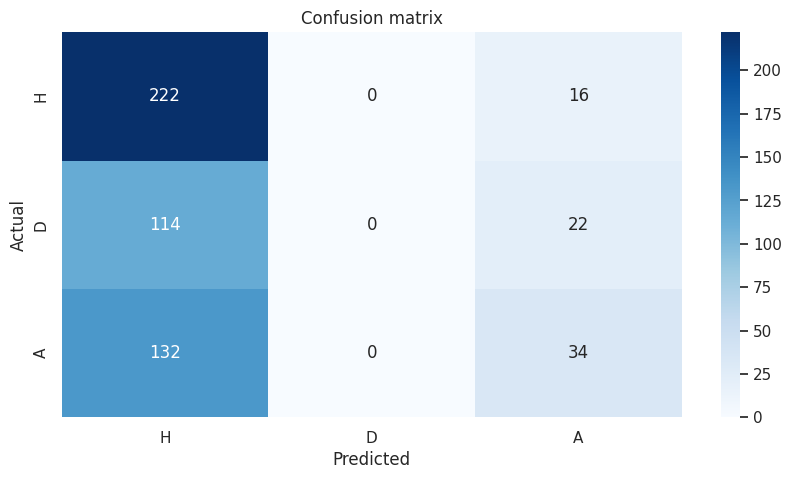

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_model.predict(X_test_best), labels=["H", "D", "A"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["H", "D", "A"], yticklabels=["H", "D", "A"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

## Part 5 - Feature Importance

This part answers the question our project set out to ask: which stat matters most for
the result? We look at it two ways.

### Importance from the Random Forest
The forest records how useful each feature was while it was training. This is quick and easy, but it
tends to favour features with lots of different values, so we treat it as a first look rather than
the final word.

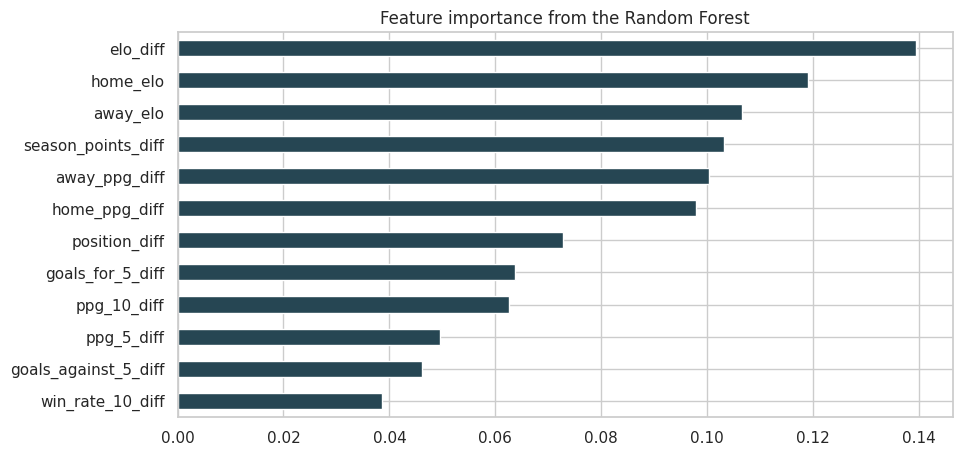

In [47]:
forest_importance = pd.Series(forest.feature_importances_, index=features).sort_values()

forest_importance.plot(kind="barh", color="#264653")
plt.title("Feature importance from the Random Forest")
plt.show()

### Permutation importance
This is the measure to trust. We take the test set, shuffle one feature so its values become random,
and see how much the log loss gets worse. If shuffling a feature hurts a lot, the model really relied
on it. If nothing happens, the feature was not pulling its weight. Because it is measured on the
unseen 2025 season, it reflects real predictive value.

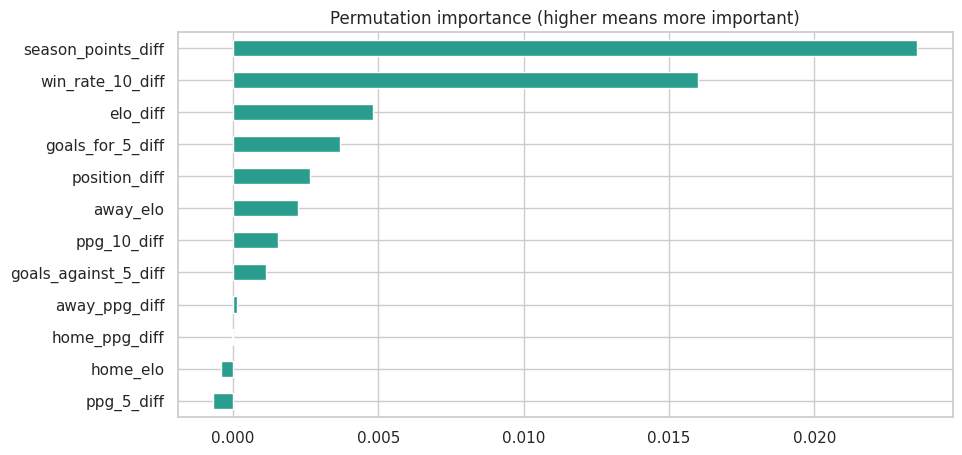

In [48]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_model, X_test_best, y_test, n_repeats=30,
                              random_state=42, scoring="neg_log_loss")

perm_importance = pd.Series(perm.importances_mean, index=features).sort_values()
perm_importance.plot(kind="barh", color="#2a9d8f")
plt.title("Permutation importance (higher means more important)")
plt.show()

### The most important feature
The single feature the model relied on most.

In [49]:
perm_importance.sort_values(ascending=False).head(8).round(5)

,0
season_points_diff,0.02355
win_rate_10_diff,0.01601
elo_diff,0.00481
goals_for_5_diff,0.00368
position_diff,0.00265
away_elo,0.00224
ppg_10_diff,0.00154
goals_against_5_diff,0.00113


### What the results mean

A few things stand out.

First, all the numbers are small. That is not a failure. It just reflects that no single stat explains
much of a football result, which is exactly why the models only edge past the baseline.

Second, league position is clearly the strongest feature here, more than twice the next one. Season
points follows, then recent form over the last 10 games. So where a team sits in the table carries
real information: it is a summary of everything the team has done all season, compressed into one
number.

Third, Elo lands in the middle rather than at the top. That is a bit surprising, since Elo is meant to
be a strong all-round rating. The likely reason is MLS itself: the salary cap keeps the teams close,
rosters change a lot every winter, and new teams keep joining, so Elo never builds the long stable
history that makes it powerful in older, more settled leagues.

One honest note on the position result. Position looks strong here partly because this feature set is
small. Position, season points, and long-run form all describe the same underlying thing, which is how
good the team has been this year. When features overlap like that, permutation importance splits the
credit between them, so adding more season-level features would pull position's score down without the
model actually getting any better. The safer way to read this chart is by group: season-long quality
beats short-term form, and both beat rest and home/away splits.

## Part 6 - Predicting the Season Winner

A match model gives the chance of each result for one game. To name a champion we have to play out the
rest of the season. We refit the model on every finished match, find the games still to come in 2026,
predict each one, and then simulate the remaining season many times to see who comes out on top.

### Refitting on every finished match
For the live prediction there is no reason to hold 2025 back, so we train on all the completed matches, including the 2026 games already played.

In [50]:
final_scaler = StandardScaler()
X_final_scaled = final_scaler.fit_transform(matches[features])

final_model = LogisticRegression(max_iter=2000, C=0.5)
final_model.fit(X_final_scaled, matches["result"])

LogisticRegression(C=0.5, max_iter=2000)

### Each team's latest form
We take the most recent row for every team, which holds its current Elo, form, and position. These are the numbers we use to predict the remaining games.

In [51]:
latest = games.sort_values("date").groupby("team").tail(1).set_index("team")
latest[["ppg_5", "position", "home_ppg"]].head(30)

,ppg_5,position,home_ppg
team,,,
New York City FC,2.0,5.0,1.672046
Toronto FC,0.4,11.0,1.662351
Atlanta United,0.4,15.0,1.518519
Philadelphia Union,1.4,14.0,1.687611
Orlando City SC,2.0,10.0,1.672575
New York Red Bulls,1.4,7.0,1.668639
CF Montréal,0.4,13.0,1.523962
New England Revolution,1.4,3.0,1.658200
Los Angeles FC,2.4,1.0,1.650538


In [52]:
display(latest.loc[["Toronto FC", "Nashville SC", "Vancouver Whitecaps"], ["date", "season", "conference", "season_points", "points", "position"]])

,date,season,conference,season_points,points,position
team,,,,,,
Toronto FC,2026-07-31 23:30:00,2026,East,16.0,1,11.0
Nashville SC,2026-08-01 23:30:00,2026,East,39.0,1,1.0
Vancouver Whitecaps,2026-08-01 23:30:00,2026,West,33.0,1,1.0


### The current 2026 table
How many points each team has so far this season. The simulation will add to these totals.

In [53]:
season_2026 = games[games["season"] == 2026]
current_points = season_2026.groupby("team")["points"].sum()
current_points.sort_values(ascending=False).head(10)

,points
team,
Nashville SC,40
Inter Miami CF,38
Vancouver Whitecaps,34
Los Angeles FC,34
San Jose Earthquakes,33
New England Revolution,30
Chicago Fire,29
Houston Dynamo,29
FC Dallas,27


### The games still to come
MLS teams play every other team in their own conference at home and away. So any pairing inside a
conference that has not yet been played this season is still to come. We build that list of remaining
fixtures.

In [54]:
played = set()
for i in season_2026.index:
    if season_2026.at[i, "is_home"] == 1:
        played.add((season_2026.at[i, "team"], season_2026.at[i, "opponent"]))

fixtures = []
for home_team in conference:
    for away_team in conference:
        if home_team != away_team and conference[home_team] == conference[away_team]:
            if (home_team, away_team) not in played:
                fixtures.append((home_team, away_team))

fixtures = pd.DataFrame(fixtures, columns=["home_team", "away_team"])
print(len(fixtures), "games remaining")

200 games remaining


### Building the features for each remaining game
For every upcoming fixture we take the home team's latest stats minus the away team's, exactly as we did for training.

In [55]:
for name in feature_names:
    fixtures[name + "_diff"] = latest.loc[fixtures["home_team"], name].values - latest.loc[fixtures["away_team"], name].values

fixtures["home_elo"] = [rating[t] for t in fixtures["home_team"]]
fixtures["away_elo"] = [rating[t] for t in fixtures["away_team"]]
fixtures["elo_diff"] = fixtures["home_elo"] - fixtures["away_elo"]

### Predicting each remaining game
The model gives the chance of a home win, draw, and away win for every fixture still to play.

In [62]:
X_fixtures_scaled = final_scaler.transform(fixtures[features])
probabilities = final_model.predict_proba(X_fixtures_scaled)
class_order = list(final_model.classes_)

fixtures["p_home"] = probabilities[:, class_order.index("H")]
fixtures["p_draw"] = probabilities[:, class_order.index("D")]
fixtures["p_away"] = probabilities[:, class_order.index("A")]

fixtures[["home_team", "away_team", "p_home", "p_draw", "p_away"]].head().round(3)

,home_team,away_team,p_home,p_draw,p_away
0,Atlanta United,Charlotte FC,0.336,0.250,0.414
1,Atlanta United,Chicago Fire,0.323,0.251,0.427
2,Atlanta United,FC Cincinnati,0.282,0.228,0.490
3,Atlanta United,Inter Miami CF,0.189,0.274,0.536
4,Atlanta United,New York City FC,0.310,0.262,0.427


In [74]:
fixtures["home_pos"] = fixtures["home_team"].map(latest["position"]).astype(int)
fixtures["away_pos"] = fixtures["away_team"].map(latest["position"]).astype(int)

fixtures = fixtures[["home_team", "home_pos", "away_team", "away_pos", "home_elo", "away_elo", "elo_diff", "p_home", "p_draw", "p_away"]]
fixtures = fixtures.round(3)
fixtures.to_csv("fixtures.csv", index=False)

### Simulating the rest of the season
Now we play the remaining season 10,000 times. In each run, every remaining game is decided at random
using its own probabilities, the points are added to what each team already has, and we record the
final table. Doing this thousands of times turns single-game chances into an overall picture of how
the season is likely to end.

We pull the fixture columns out into plain lists first. Reading from a pandas table inside a loop that
runs two million times is very slow, while reading from a list is instant.

In [81]:
number_of_simulations = 10000
np.random.seed(42)

home_list = list(fixtures["home_team"])
away_list = list(fixtures["away_team"])
p_home_list = list(fixtures["p_home"])
p_draw_list = list(fixtures["p_draw"])

start_points = dict(current_points)

titles = {}
shields = {}
for team in start_points:
    titles[team] = 0
    shields[team] = 0

### Running the simulation loop
We use the Elo ratings again for the knockout playoff at the end, where the higher-rated team is more likely to win.

In [82]:
for sim in range(number_of_simulations):
    points = dict(start_points)

    random_numbers = np.random.random(len(home_list))
    for i in range(len(home_list)):
        r = random_numbers[i]
        if r < p_home_list[i]:
            points[home_list[i]] = points[home_list[i]] + 3
        elif r < p_home_list[i] + p_draw_list[i]:
            points[home_list[i]] = points[home_list[i]] + 1
            points[away_list[i]] = points[away_list[i]] + 1
        else:
            points[away_list[i]] = points[away_list[i]] + 3

    table = sorted(points, key=points.get, reverse=True)
    shields[table[0]] = shields[table[0]] + 1

    finalists = []
    for conf in ["East", "West"]:
        seeds = [t for t in table if conference[t] == conf][:8]
        while len(seeds) > 1:
            winners = []
            for j in range(len(seeds) // 2):
                a = seeds[j]
                b = seeds[len(seeds) - 1 - j]
                p_a = 1 / (1 + 10 ** (-((rating[a] + 40 - rating[b]) / 400)))
                if np.random.random() < p_a:
                    winners.append(a)
                else:
                    winners.append(b)
            seeds = winners
        finalists.append(seeds[0])

    a = finalists[0]
    b = finalists[1]
    p_a = 1 / (1 + 10 ** (-((rating[a] - rating[b]) / 400)))
    if np.random.random() < p_a:
        titles[a] = titles[a] + 1
    else:
        titles[b] = titles[b] + 1

### Supporters' Shield chances
The Supporters' Shield goes to the team with the most points in the whole league. Here is how often each team finished top across the simulations.

In [83]:
shield_chances = pd.Series(shields) / number_of_simulations * 100
shield_chances = shield_chances.sort_values(ascending=False)
shield_chances.head(10).round(1)

,0
Inter Miami CF,75.4
Nashville SC,14.0
Vancouver Whitecaps,6.5
San Jose Earthquakes,2.4
Los Angeles FC,1.6
FC Cincinnati,0.1
New York City FC,0.1
Houston Dynamo,0.1
Chicago Fire,0.0
FC Dallas,0.0


### MLS Cup chances
The actual MLS champion is decided by a knockout playoff, so finishing top does not guarantee the title. Here is how often each team won the Cup in the simulations.

In [84]:
cup_chances = pd.Series(titles) / number_of_simulations * 100
cup_chances = cup_chances.sort_values(ascending=False)
cup_chances.head(10).round(1)

,0
Inter Miami CF,30.2
Vancouver Whitecaps,16.3
Los Angeles FC,16.0
Nashville SC,9.6
New York City FC,3.9
FC Cincinnati,3.9
FC Dallas,2.4
Houston Dynamo,1.9
San Jose Earthquakes,1.9
Chicago Fire,1.8


### The final picture
Both trophies side by side. The gap between them is the story of MLS: the Shield rewards being consistent all season, while the Cup is a short knockout that often springs a surprise.

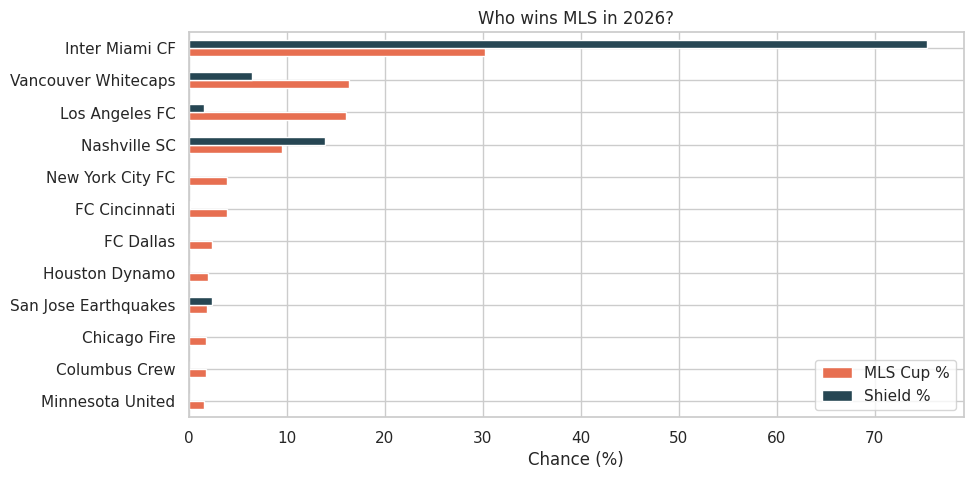

,MLS Cup %,Shield %
Inter Miami CF,30.2,75.4
Vancouver Whitecaps,16.3,6.5
Los Angeles FC,16.0,1.6
Nashville SC,9.6,14.0
New York City FC,3.9,0.1
FC Cincinnati,3.9,0.1
FC Dallas,2.4,0.0
Houston Dynamo,1.9,0.1
San Jose Earthquakes,1.9,2.4
Chicago Fire,1.8,0.0


In [85]:
summary = pd.DataFrame({"MLS Cup %": cup_chances, "Shield %": shield_chances}).fillna(0)
summary = summary.sort_values("MLS Cup %", ascending=False)

top12 = summary.head(12).sort_values("MLS Cup %")
top12.plot(kind="barh", color=["#e76f51", "#264653"])
plt.title("Who wins MLS in 2026?")
plt.xlabel("Chance (%)")
plt.show()

summary.head(12).round(1)

## Part 7 - Predicting a Single Match

Finally, a simple way to predict any one game. Pick two teams and the model gives the chance of each
result. The names have to match the dataset exactly.

### Choose the two teams

In [86]:
home_team = "Los Angeles FC"
away_team = "Seattle Sounders FC"

### Build the features for this match
We take the two teams' latest stats and turn them into the same differences our model was trained on.

In [87]:
one_game = {}
for name in feature_names:
    one_game[name + "_diff"] = latest.loc[home_team, name] - latest.loc[away_team, name]

one_game["home_elo"] = rating[home_team]
one_game["away_elo"] = rating[away_team]
one_game["elo_diff"] = rating[home_team] - rating[away_team]

one_game = pd.DataFrame([one_game])[features]

### The prediction

In [88]:
one_game = {}
for name in feature_names:
    one_game[name + "_diff"] = latest.loc[home_team, name] - latest.loc[away_team, name]

one_game["home_elo"] = rating[home_team]
one_game["away_elo"] = rating[away_team]
one_game["elo_diff"] = rating[home_team] - rating[away_team]

one_game = pd.DataFrame([one_game])[features]

X_one_game_scaled = final_scaler.transform(one_game)
prediction = final_model.predict_proba(X_one_game_scaled)[0]
order = list(final_model.classes_)

home_pos = int(latest.loc[home_team, "position"])
home_conf = conference[home_team]
away_pos = int(latest.loc[away_team, "position"])
away_conf = conference[away_team]

print(f"{home_team} ({home_conf}, Pos: {home_pos}) win: {round(prediction[order.index('H')], 3)}")
print(f"Draw: {round(prediction[order.index('D')], 3)}")
print(f"{away_team} ({away_conf}, Pos: {away_pos}) win: {round(prediction[order.index('A')], 3)}")

Los Angeles FC (West, Pos: 1) win: 0.583
Draw: 0.267
Seattle Sounders FC (West, Pos: 8) win: 0.149


## Notes and Next Steps

The dataset only has results, so every feature here was built from dates, teams, and goals. The single
biggest improvement would be to add expected goals (xG), which measures the quality of chances rather
than just the final score. It usually predicts better than raw goals, because a lucky 1-0 and a
dominant 1-0 look identical in the score line but very different in xG.

Other useful additions, roughly in order: travel distance between games, which is unusually punishing
in MLS, injuries and suspensions, and altitude for games in Colorado and Utah.


In [89]:
import joblib

joblib.dump(final_model, 'mls_model.joblib')
joblib.dump(final_scaler, 'mls_scaler.joblib')


summary.to_csv('season_simulation_summary.csv')

print("Saved mls_model.joblib, mls_scaler.joblib, and season_simulation_summary.csv successfully!")

Saved mls_model.joblib, mls_scaler.joblib, and season_simulation_summary.csv successfully!
